# Human Immune Health Atlas: sample representation benchmark

Blood immune single-cell data from the Dynamics of Immune Health and Age study (Nature 2025, [PMID 41162704](https://pubmed.ncbi.nlm.nih.gov/41162704/)). Donors vary in age and CMV status; cells are annotated with Allen Institute AIFI labels at several resolutions.

Download `human_immune_health_atlas_full.h5ad` from the Immune Health Atlas catalog:
https://apps.allenimmunology.org/aifi/resources/imm-health-atlas/downloads/scrna/

Direct link to the full object (on the order of 40 GB):
https://allenimmunology.org/public/publication/download/84792154-cdfb-42d0-8e42-39e210e980b4/filesets/568ad40c-516a-4646-9426-bdcd7029c1f5/human_immune_health_atlas_full.h5ad


## CLR composition

`CellGroupComposition(apply_clr=True)` builds per-sample cell type proportions and applies a centered log-ratio (CLR) so distances are not driven only by total abundance. The other methods in the benchmark use the same label column but aggregate cells in different ways.


## Install patpy


In [1]:
!pip install git+https://github.com/lueckenlab/patpy.git@main
!pip install -q pilotpy


  Cloning https://github.com/lueckenlab/patpy.git (to revision main) to /private/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/pip-req-build-_bipsg6h
  Running command git clone --filter=blob:none --quiet https://github.com/lueckenlab/patpy.git /private/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/pip-req-build-_bipsg6h
  Resolved https://github.com/lueckenlab/patpy.git to commit 270d75cd34cb1382c66823df68c6e7f054341e70
  Running command git submodule update --init --recursive -q
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## Import packages


In [2]:
import warnings

import matplotlib.cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.collections import LineCollection
from matplotlib.patches import Ellipse
from matplotlib.colors import LinearSegmentedColormap
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import bar
from scipy import stats
from sklearn.decomposition import PCA

import patpy

warnings.filterwarnings("ignore", category=UserWarning)


## Read the data

Set `ADATA_PATH` to your local `human_immune_health_atlas_full.h5ad`. The object should have `obsm['X_pca']` (used by pseudobulk-style methods).


In [3]:
ADATA_PATH = "/Users/kylekimler/Projects/patient-maps-playground/data/human_immune_health_atlas_full.h5ad"


In [4]:
adata = sc.read_h5ad(ADATA_PATH)
adata


AnnData object with n_obs × n_vars = 1821725 × 1236
    obs: 'cohort.cohortGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid', 'pipeline.fileGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.birthYear', 'subject.ageAtFirstDraw', 'subject.ageGroup', 'subject.race', 'subject.ethnicity', 'subject.cmv', 'subject.bmi', 'sample.visitName', 'sample.drawYear', 'sample.subjectAgeAtDraw', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'barcodes', 'original_barcodes', 'cell_name', 'n_reads', 'n_umis', 'n_genes', 'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3'
    var: 'mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'AIFI_L1_colors', 'AIFI_L2_colors', 'AIFI_L3_colors', 'celltypist.low_colors', 'hvg', 'keep_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'seurat.

## Benchmark

For each AIFI resolution (L1–L3) and each method—including **PILOT** (Earth Mover's distances via `pilotpy`)—build sample distances and score them with KNN. Biological **relevant** targets and **technical** batch proxies use the same normalization as `knn_prediction_score` (technical scores inverted; Spearman scores taken in absolute value). Results are summarized in the **plottable `Table()`** (see `representation_methods_example.ipynb`).

This loop reuses the same `adata`; if you hit odd state, restart from a fresh `read_h5ad`. **PILOT** can be slow on the full atlas; reduce cells or samples if needed.


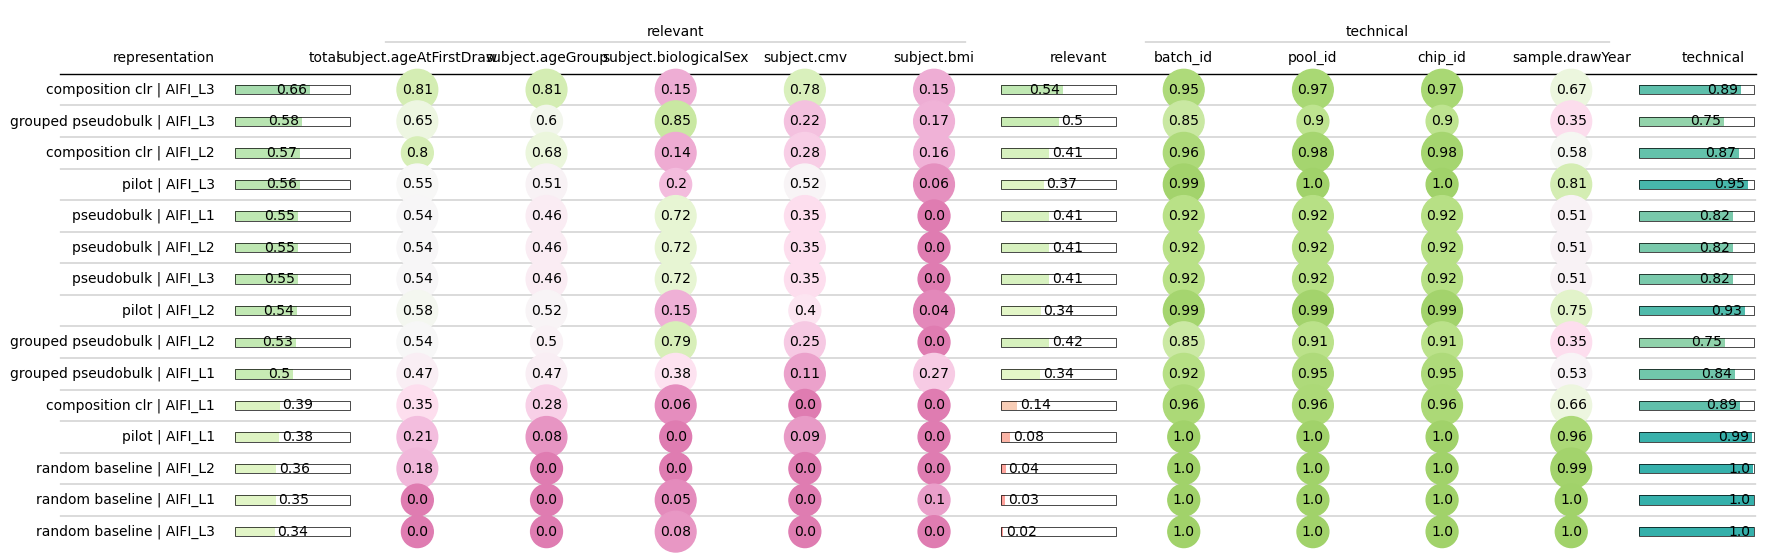

,label_key,method,bio_mean,tech_mean,mean_score
0,AIFI_L3,composition_clr,0.539334,0.890407,0.714870
1,AIFI_L3,pilot,0.366612,0.950140,0.658376
2,AIFI_L2,composition_clr,0.412431,0.872550,0.642490
3,AIFI_L2,pilot,0.340117,0.927951,0.634034
4,AIFI_L3,grouped_pseudobulk,0.497230,0.746433,0.621831
5,AIFI_L1,pseudobulk,0.413976,0.817714,0.615845
6,AIFI_L2,pseudobulk,0.413976,0.817714,0.615845
7,AIFI_L3,pseudobulk,0.413976,0.817714,0.615845
8,AIFI_L1,grouped_pseudobulk,0.338105,0.838025,0.588065
9,AIFI_L2,grouped_pseudobulk,0.417398,0.754882,0.586140


In [5]:
SAMPLE_KEY = "sample.sampleKitGuid"
LABEL_RESOLUTIONS = ["AIFI_L1", "AIFI_L2", "AIFI_L3"]
PILOT_SAMPLE_STATE_COL = "pilot.sampleState"
# Columns used only for UMAP coloring below
AGE_COL = "subject.ageAtFirstDraw"
CMV_COL = "subject.cmv"
RNG = 67
N_NEIGHBORS = 7

# PILOT expects a per-cell status column (constant is fine for a single-cohort atlas)
if PILOT_SAMPLE_STATE_COL not in adata.obs.columns:
    adata.obs[PILOT_SAMPLE_STATE_COL] = "nominal"

# KNN tasks per covariate; "relevant" = biological, "technical" = batch / processing
BENCHMARK_SCHEMA = {
    "relevant": {
        "subject.ageAtFirstDraw": "regression",
        "subject.ageGroup": "classification",
        "subject.biologicalSex": "classification",
        "subject.cmv": "classification",
        "subject.bmi": "regression",
    },
    "technical": {
        "batch_id": "classification",
        "pool_id": "classification",
        "chip_id": "classification",
        "sample.drawYear": "regression",
    },
}

REQ_OBS = (
    {SAMPLE_KEY, CMV_COL, AGE_COL, *LABEL_RESOLUTIONS}
    | {c for bucket in BENCHMARK_SCHEMA.values() for c in bucket}
)

for col in REQ_OBS:
    assert col in adata.obs, col
assert "X_pca" in adata.obsm, "need X_pca in obsm for pseudobulk methods"


def build_method(method: str, label_key: str):
    if method == "composition_clr":
        return patpy.tl.CellGroupComposition(SAMPLE_KEY, label_key, apply_clr=True, seed=RNG)
    if method == "pseudobulk":
        return patpy.tl.Pseudobulk(SAMPLE_KEY, label_key, layer="X_pca", seed=RNG)
    if method == "grouped_pseudobulk":
        return patpy.tl.GroupedPseudobulk(SAMPLE_KEY, label_key, layer="X_pca", seed=RNG)
    if method == "random_baseline":
        return patpy.tl.RandomVector(SAMPLE_KEY, label_key, latent_dim=32, seed=RNG)
    if method == "pilot":
        return patpy.tl.PILOT(
            SAMPLE_KEY,
            label_key,
            sample_state_col=PILOT_SAMPLE_STATE_COL,
            layer="X_pca",
            seed=RNG,
        )
    raise ValueError(method)


METHOD_ORDER = ["composition_clr", "pseudobulk", "grouped_pseudobulk", "pilot", "random_baseline"]

rows: list[dict] = []
for label_key in LABEL_RESOLUTIONS:
    for method in METHOD_ORDER:
        m = build_method(method, label_key)
        m.prepare_anndata(adata)
        force = method.startswith("composition") or method == "pilot"
        m.calculate_distance_matrix(force=force)
        for covariate_type, cov_map in BENCHMARK_SCHEMA.items():
            for cov_col, task in cov_map.items():
                out = m.evaluate_representation(
                    cov_col, method="knn", n_neighbors=N_NEIGHBORS, task=task
                )
                rows.append(
                    {
                        "label_key": label_key,
                        "method": method,
                        "covariate": cov_col,
                        "covariate_type": covariate_type,
                        "task": task,
                        "score": out["score"],
                        "metric": out["metric"],
                    }
                )

benchmark_long = pd.DataFrame(rows)


def _plot_score(row: pd.Series) -> float:
    s = float(row["score"])
    if row["covariate_type"] == "technical":
        s = 1.0 - s
    if row["metric"] == "spearman_r":
        s = abs(s)
    return s


benchmark_long["plot_score"] = benchmark_long.apply(_plot_score, axis=1)

bio = benchmark_long[benchmark_long["covariate_type"] == "relevant"]
tech = benchmark_long[benchmark_long["covariate_type"] == "technical"]
summary = (
    bio.groupby(["label_key", "method"], as_index=False)["plot_score"]
    .mean()
    .rename(columns={"plot_score": "bio_mean"})
    .merge(
        tech.groupby(["label_key", "method"], as_index=False)["plot_score"]
        .mean()
        .rename(columns={"plot_score": "tech_mean"}),
        on=["label_key", "method"],
        how="outer",
    )
)
summary["mean_score"] = (summary["bio_mean"] + summary["tech_mean"]) / 2.0
results = summary.sort_values("mean_score", ascending=False).reset_index(drop=True)

knn_results_wide = benchmark_long.pivot_table(
    index=["method", "label_key"],
    columns="covariate",
    values="plot_score",
    aggfunc="first",
)

plot_df = knn_results_wide.reset_index()
plot_df["representation"] = plot_df["method"].str.replace("_", " ") + " | " + plot_df["label_key"]
plot_df = plot_df.drop(columns=["method", "label_key"]).set_index("representation")

for covariate_type, cov_map in BENCHMARK_SCHEMA.items():
    tcols = list(cov_map.keys())
    plot_df[covariate_type] = plot_df[tcols].mean(axis=1)

clin_weight = 2 / 3
plot_df["total"] = clin_weight * plot_df["relevant"] + (1 - clin_weight) * plot_df["technical"]

cols_order = ["total"]
for covariate_type in BENCHMARK_SCHEMA:
    cols_order.extend(list(BENCHMARK_SCHEMA[covariate_type].keys()))
    cols_order.append(covariate_type)

cmap = LinearSegmentedColormap.from_list(
    name="bugw", colors=["#FF9693", "#f2fbd2", "#c9ecb4", "#93d3ab", "#35b0ab"], N=256
)

col_defs: list = []
col_defs.append(
    ColumnDefinition(
        "total",
        width=0.7,
        plot_fn=bar,
        plot_kw={
            "cmap": cmap,
            "plot_bg_bar": True,
            "annotate": True,
            "height": 0.5,
            "lw": 0.5,
            "formatter": lambda x: round(x, 2),
        },
    )
)

for covariate_type in BENCHMARK_SCHEMA:
    type_cols = list(BENCHMARK_SCHEMA[covariate_type].keys())
    for col in type_cols:
        col_defs.append(
            ColumnDefinition(
                name=col,
                width=0.75,
                formatter=lambda x: round(x, 2),
                textprops={"ha": "center", "bbox": {"boxstyle": "circle", "pad": 0.35}},
                cmap=normed_cmap(benchmark_long["plot_score"], cmap=matplotlib.cm.PiYG, num_stds=2.5),
                group=covariate_type,
            )
        )
    col_defs.append(
        ColumnDefinition(
            covariate_type,
            width=0.7,
            plot_fn=bar,
            plot_kw={
                "cmap": cmap,
                "plot_bg_bar": True,
                "annotate": True,
                "height": 0.5,
                "lw": 0.5,
                "formatter": lambda x: round(x, 2),
            },
        )
    )

fig, ax = plt.subplots(figsize=(22, 7))
Table(
    plot_df[cols_order].sort_values("total", ascending=False),
    column_definitions=tuple(col_defs),
    ax=ax,
)
plt.show()

results


## KNN vs PERMANOVA: CLR and PILOT

For each AIFI resolution and each representation (**CLR composition** vs **PILOT**), we compare **KNN** (calibrated macro-F1), **PERMANOVA pseudo-F**, and **permutation p-values** as :math:`-\log_{10}(p)`.

A second figure traces **CMV** across **L1–L3** for CLR and PILOT (KNN, pseudo-F, and :math:`-\log_{10}(p)`).

The section below is an **ordination-style** view for **CLR · AIFI_L3**: **95%** normal-theory **CMV ellipses** on sample **PCA** of CLR compositions (similar in spirit to **vegan** ordination ellipses), with **PERMANOVA** for CMV in a legend box. Beside it: the **same PCA** with **kNN edges** from the **sample distance matrix**, with the **KNN** CMV score annotated.


In [ ]:
PERMANOVA_PERMUTATIONS = 499

compare_covariates = {
    "subject.cmv": "CMV status",
    "subject.ageGroup": "Age group",
    "subject.biologicalSex": "Biological sex",
}

METHOD_LABELS = {"CLR": "CLR composition", "PILOT": "PILOT"}


def _build_repr_perm(method_key: str, label_key: str):
    if method_key == "CLR":
        return patpy.tl.CellGroupComposition(SAMPLE_KEY, label_key, apply_clr=True, seed=RNG)
    if method_key == "PILOT":
        return patpy.tl.PILOT(
            SAMPLE_KEY,
            label_key,
            sample_state_col=PILOT_SAMPLE_STATE_COL,
            layer="X_pca",
            seed=RNG,
        )
    raise ValueError(method_key)


perm_rows = []
for label_key in LABEL_RESOLUTIONS:
    for method_key in ("CLR", "PILOT"):
        m = _build_repr_perm(method_key, label_key)
        m.prepare_anndata(adata)
        m.calculate_distance_matrix(force=True)
        for cov_col in compare_covariates:
            knn_out = m.evaluate_representation(
                cov_col, method="knn", n_neighbors=N_NEIGHBORS, task="classification"
            )
            perm_out = m.evaluate_representation(
                cov_col, method="permanova", permutations=PERMANOVA_PERMUTATIONS
            )
            perm_rows.append(
                {
                    "label_key": label_key,
                    "repr_method": method_key,
                    "covariate": cov_col,
                    "knn": knn_out["score"],
                    "permanova_pseudo_f": perm_out["score"],
                    "permanova_p": perm_out["p_value"],
                }
            )

perm_df = pd.DataFrame(perm_rows)
p_floor = 1.0 / (PERMANOVA_PERMUTATIONS + 1)
perm_df["neglog10_p"] = -np.log10(perm_df["permanova_p"].clip(lower=p_floor))


def _bars_clr_pilot(ax, df_cov, ycol, ylabel, title):
    x = np.arange(len(LABEL_RESOLUTIONS))
    w = 0.36
    for i, mk in enumerate(["CLR", "PILOT"]):
        sub = df_cov[df_cov["repr_method"] == mk].set_index("label_key").reindex(LABEL_RESOLUTIONS)
        offset = (i - 0.5) * w
        ax.bar(
            x + offset,
            sub[ycol],
            w,
            label=METHOD_LABELS[mk],
            alpha=0.92,
            edgecolor="white",
            linewidth=0.6,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(LABEL_RESOLUTIONS, rotation=14, ha="right")
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, frameon=True)
    ax.grid(axis="y", alpha=0.28, ls="-", lw=0.5)
    ax.set_axisbelow(True)


fig, axes = plt.subplots(3, 3, figsize=(15.5, 11), layout="constrained")
metric_rows = [
    ("knn", "KNN (calibrated F1)"),
    ("permanova_pseudo_f", "PERMANOVA pseudo-F"),
    ("neglog10_p", r"$-\log_{10}(p)$ PERMANOVA"),
]
for j, (cov_col, nice_name) in enumerate(compare_covariates.items()):
    dc = perm_df[perm_df["covariate"] == cov_col]
    for r, (ycol, ylab) in enumerate(metric_rows):
        _bars_clr_pilot(axes[r, j], dc, ycol, ylab, nice_name if r == 0 else "")

fig.suptitle(
    "CLR vs PILOT: KNN, PERMANOVA pseudo-F, and permutation p-values",
    fontsize=13,
    y=1.01,
)
plt.show()

cmv_df = perm_df[perm_df["covariate"] == "subject.cmv"].copy()
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2), layout="constrained")
markers = {"CLR": "o", "PILOT": "s"}
ylabs = ["KNN (calibrated F1)", "PERMANOVA pseudo-F", r"$-\log_{10}(p)$ PERMANOVA"]
ycols = ["knn", "permanova_pseudo_f", "neglog10_p"]
for ax, ycol, ylab in zip(axes, ycols, ylabs, strict=True):
    for mk in ("CLR", "PILOT"):
        sub = cmv_df[cmv_df["repr_method"] == mk].set_index("label_key").reindex(LABEL_RESOLUTIONS)
        ax.plot(
            LABEL_RESOLUTIONS,
            sub[ycol],
            marker=markers[mk],
            label=METHOD_LABELS[mk],
            lw=2.2,
            ms=8,
        )
    ax.set_ylabel(ylab)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
fig.suptitle("CMV across AIFI resolutions (CLR vs PILOT)", fontsize=12)
plt.show()


## CLR · AIFI_L3 ordination: CMV ellipses and kNN graph

**Left:** PCA of per-sample CLR compositions at **AIFI_L3**; **95%** bivariate normal confidence **ellipses** per **CMV** level (ordination ellipse style). An annotation box summarizes **PERMANOVA** (pseudo-F and permutation **p-value**) on the **same** Euclidean distance matrix used for CLR in patpy.

**Right:** identical PCA coordinates; line segments connect each sample to its **k** nearest neighbors **in the full sample distance matrix**. An annotation box gives the **KNN** benchmark result for CMV (**k** matches `N_NEIGHBORS` above).


In [ ]:
ELLIPSE_CHI2 = stats.chi2.ppf(0.95, 2)
ORD_LABEL = "AIFI_L3"
N_EDGE = int(min(N_NEIGHBORS, 12))

m_ord = patpy.tl.CellGroupComposition(SAMPLE_KEY, ORD_LABEL, apply_clr=True, seed=RNG)
m_ord.prepare_anndata(adata)
D_ord = np.asarray(m_ord.calculate_distance_matrix(force=True), dtype=float).copy()
X_ord = np.asarray(m_ord.sample_representation, dtype=float)
samples_ord = list(m_ord.sample_representation.index)
sample_table = adata.obs.drop_duplicates(subset=[SAMPLE_KEY], keep="first").set_index(SAMPLE_KEY)
cmv_ord = sample_table.loc[samples_ord, CMV_COL].astype(str)

pca_ord = PCA(n_components=2, random_state=RNG)
XY_ord = pca_ord.fit_transform(X_ord)

perm_ord = m_ord.evaluate_representation(
    CMV_COL, method="permanova", permutations=PERMANOVA_PERMUTATIONS
)
knn_ord = m_ord.evaluate_representation(
    CMV_COL, method="knn", n_neighbors=N_NEIGHBORS, task="classification"
)


def _ellipse_mu_wh_theta(xy: np.ndarray):
    if xy.shape[0] < 3:
        return None
    cov = np.cov(xy.T)
    det = np.linalg.det(cov)
    if det < 1e-14:
        return None
    mu = xy.mean(axis=0)
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals = np.maximum(vals[order], 1e-12)
    vecs = vecs[:, order]
    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w = 2 * np.sqrt(ELLIPSE_CHI2 * vals[0])
    h = 2 * np.sqrt(ELLIPSE_CHI2 * vals[1])
    return mu, w, h, theta


D_nn = D_ord.copy()
np.fill_diagonal(D_nn, np.inf)
n_s = D_nn.shape[0]
edge_pairs = []
if n_s > 1:
    k_take = min(N_EDGE, n_s - 1)
    for i in range(n_s):
        part = np.argpartition(D_nn[i], k_take - 1)[:k_take]
        nn = part[part != i]
        if len(nn) == 0:
            continue
        nn = nn[np.argsort(D_nn[i, nn])]
        for j in nn[:N_EDGE]:
            edge_pairs.append((i, int(j)))

segments = [[XY_ord[i], XY_ord[j]] for i, j in edge_pairs]
levels = sorted(cmv_ord.unique())
_q = np.linspace(0.08, 0.92, max(len(levels), 1))
color_cmv = {lev: plt.cm.Spectral(_q[i]) for i, lev in enumerate(levels)}

fig, (ax_e, ax_g) = plt.subplots(
    1,
    2,
    figsize=(14.2, 6.2),
    layout="constrained",
    facecolor="#f6f6f4",
)
for ax in (ax_e, ax_g):
    ax.set_facecolor("#fafaf8")

for lev in levels:
    sel = (cmv_ord == lev).to_numpy()
    pts = XY_ord[sel]
    col = color_cmv[lev]
    ell = _ellipse_mu_wh_theta(pts)
    if ell is not None:
        mu, w_r, h_r, th = ell
        ax_e.add_patch(
            Ellipse(
                xy=mu,
                width=w_r,
                height=h_r,
                angle=th,
                facecolor=col,
                edgecolor=col,
                lw=1.6,
                alpha=0.2,
                zorder=1,
            )
        )
    ax_e.scatter(
        pts[:, 0],
        pts[:, 1],
        s=46,
        color=col,
        alpha=0.92,
        edgecolors="white",
        linewidths=0.65,
        label=f"CMV {lev}",
        zorder=3,
    )

perm_lines = (
    "PERMANOVA (CMV)"
    + chr(10)
    + f"pseudo-F = {perm_ord['score']:.4g}"
    + chr(10)
    + f"p = {perm_ord['p_value']:.4g}"
    + chr(10)
    + f"({PERMANOVA_PERMUTATIONS} permutations)"
)
ax_e.text(
    0.03,
    0.97,
    perm_lines,
    transform=ax_e.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    linespacing=1.35,
    bbox=dict(boxstyle="round,pad=0.55", facecolor="white", edgecolor="#222", alpha=0.95, linewidth=0.85),
)
ax_e.set_xlabel(f"PC1 ({pca_ord.explained_variance_ratio_[0] * 100:.1f}%)")
ax_e.set_ylabel(f"PC2 ({pca_ord.explained_variance_ratio_[1] * 100:.1f}%)")
ax_e.set_title("PCA of CLR composition — 95% CMV ellipses", fontsize=12.5)
ax_e.legend(framealpha=0.94, loc="best", fontsize=9)
ax_e.grid(True, alpha=0.22)

if segments:
    ax_g.add_collection(
        LineCollection(segments, colors="#5c5c5c", alpha=0.4, linewidths=0.75, zorder=0)
    )
for lev in levels:
    sel = (cmv_ord == lev).to_numpy()
    pts = XY_ord[sel]
    col = color_cmv[lev]
    ax_g.scatter(
        pts[:, 0],
        pts[:, 1],
        s=46,
        color=col,
        alpha=0.92,
        edgecolors="white",
        linewidths=0.65,
        label=f"CMV {lev}",
        zorder=3,
    )

knn_lines = (
    "KNN (CMV)"
    + chr(10)
    + f"k = {N_NEIGHBORS}"
    + chr(10)
    + f"score = {knn_ord['score']:.4f}"
    + chr(10)
    + f"metric = {knn_ord['metric']}"
)
ax_g.text(
    0.03,
    0.97,
    knn_lines,
    transform=ax_g.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    linespacing=1.35,
    bbox=dict(boxstyle="round,pad=0.55", facecolor="white", edgecolor="#222", alpha=0.95, linewidth=0.85),
)
ax_g.set_xlabel(f"PC1 ({pca_ord.explained_variance_ratio_[0] * 100:.1f}%)")
ax_g.set_ylabel(f"PC2 ({pca_ord.explained_variance_ratio_[1] * 100:.1f}%)")
ax_g.set_title(f"Same PCA — distance kNN edges (k ≤ {N_EDGE})", fontsize=12.5)
ax_g.legend(framealpha=0.94, loc="best", fontsize=9)
ax_g.grid(True, alpha=0.22)
ax_g.set_xlim(ax_e.get_xlim())
ax_g.set_ylim(ax_e.get_ylim())

fig.suptitle("AIFI_L3 · CLR sample space: global CMV structure vs local neighborhoods", fontsize=13.5, y=1.03)
plt.show()


## UMAP on distances for top runs

Refit the two highest `mean_score` rows and plot UMAP on the distance matrix colored by age and CMV.


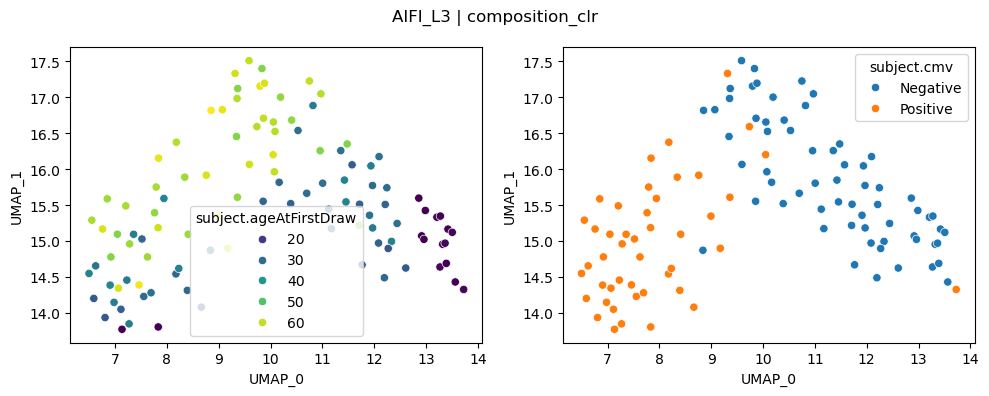

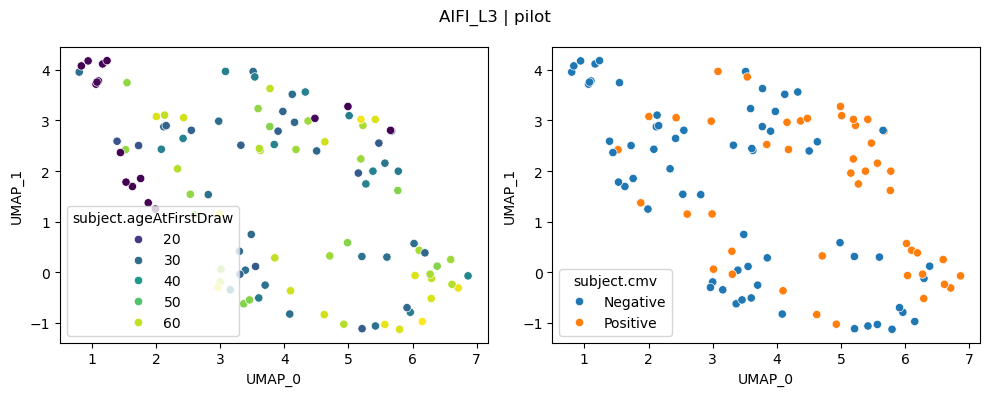

In [7]:
top2 = results.sort_values("mean_score", ascending=False).head(2)
for _, row in top2.iterrows():
    label_key = row["label_key"]
    method = row["method"]
    m = build_method(method, label_key)
    m.prepare_anndata(adata)
    m.calculate_distance_matrix(force=method.startswith("composition"))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    m.plot_embedding(method="UMAP", metadata_cols=[AGE_COL, CMV_COL], axes=axes)
    fig.suptitle(f"{label_key} | {method}")
    plt.tight_layout()


## Results

Compare `mean_score` (average of per-target scores after the same normalization as the SPARE-style benchmark) across rows. High **bio_mean** means donor metadata is easy to read from neighbor geometry; high **tech_mean** means batch IDs are hard to predict (better confounder control). The random baseline should be weak on biology if the pipeline is behaving.
